**1. Загрузка и первичный осмотр данных**

Для анализа данных необходимо импортировать Pandas, присвоить ему псевдоним pd. Параметр encoding='latin1' позволяет pandas корректно прочитать файл и избежать ошибок декодирования.

In [ ]:
#Импортируем библиотеку Pandas и загружаем датасет
import pandas as pd
df = pd.read_csv('Project.csv', encoding='latin1')

/tmp/ipykernel_672/750928374.py:3: DtypeWarning: Columns (17) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Project.csv', encoding='latin1')


Проверяем размер датафрейма - df.shape. В нашем случае датасет содержит 401 756 записей и 30 признаков.

In [ ]:
#Проверяем размер датафрейма
df.shape

(401756, 30)

Для вывода всех признаков используем команду columns.

In [ ]:
#Просмотрим названия всех атрибутов, их в датафрейме 30
df.columns

Index(['order_id', 'assignment_id', 'user_id', 'assistment_id', 'problem_id',
       'original', 'correct', 'attempt_count', 'ms_first_response',
       'tutor_mode', 'answer_type', 'sequence_id', 'student_class_id',
       'position', 'type', 'base_sequence_id', 'skill_id', 'skill_name',
       'teacher_id', 'school_id', 'hint_count', 'hint_total', 'overlap_time',
       'template_id', 'answer_id', 'answer_text', 'first_action',
       'bottom_hint', 'opportunity', 'opportunity_original'],
      dtype='object')

order_id — Уникальный идентификатор записи  
assignment_id — Идентификатор учебного задания  
user_id — Идентификатор ученика  
assistment_id — Идентификатор упражнения в системе ASSISTments  
problem_id — Идентификатор задания  
original — Признак исходной версии задания  
correct — Правильность ответа (1 — правильно, 0 — неправильно)  
attempt_count — Количество попыток решения  
ms_first_response — Время до первого ответа (мс)  
tutor_mode — Режим работы с подсказками  
answer_type — Тип ответа ученика  
sequence_id — Идентификатор последовательности заданий  
student_class_id — Идентификатор класса ученика  
position — Позиция задания  
type — Тип задания  
base_sequence_id — Базовый идентификатор последовательности  
skill_id — Идентификатор навыка  
skill_name — Название навыка  
teacher_id — Идентификатор преподавателя  
school_id — Идентификатор школы  
hint_count — Количество подсказок  
hint_total — Общее число подсказок  
overlap_time — Время действий пользователя  
template_id — Идентификатор шаблона задания  
answer_id — Идентификатор ответа  
answer_text — Текст ответа  
first_action — Первое действие  
bottom_hint — Использование нижней подсказки  
opportunity — Количество встреч с навыком  
opportunity_original — Исходное значение opportunity  

Просмотр первых 5 записей датафрема осуществляем с помощью команды head

In [ ]:
#Для изучения данных выведем первые 5 строк
df.head()

,order_id,assignment_id,user_id,assistment_id,problem_id,original,correct,attempt_count,ms_first_response,tutor_mode,...,hint_count,hint_total,overlap_time,template_id,answer_id,answer_text,first_action,bottom_hint,opportunity,opportunity_original
0,33022537,277618,64525,33139,51424,1,1,1,32454,tutor,...,0,3,32454,30799,NaN,26,0,NaN,1,1.0
1,33022709,277618,64525,33150,51435,1,1,1,4922,tutor,...,0,3,4922,30799,NaN,55,0,NaN,2,2.0
2,35450204,220674,70363,33159,51444,1,0,2,25390,tutor,...,0,3,42000,30799,NaN,88,0,NaN,1,1.0
3,35450295,220674,70363,33110,51395,1,1,1,4859,tutor,...,0,3,4859,30059,NaN,41,0,NaN,2,2.0
4,35450311,220674,70363,33196,51481,1,0,14,19813,tutor,...,3,4,124564,30060,NaN,65,0,0.0,3,3.0


Выводим краткую информацию о датафрейме: размер таблицы, типы данных, пропуски и использование памяти.

In [ ]:
#Просмотр краткой информации
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 401756 entries, 0 to 401755
Data columns (total 30 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              401756 non-null  int64  
 1   assignment_id         401756 non-null  int64  
 2   user_id               401756 non-null  int64  
 3   assistment_id         401756 non-null  int64  
 4   problem_id            401756 non-null  int64  
 5   original              401756 non-null  int64  
 6   correct               401756 non-null  int64  
 7   attempt_count         401756 non-null  int64  
 8   ms_first_response     401756 non-null  int64  
 9   tutor_mode            401756 non-null  object 
 10  answer_type           401756 non-null  object 
 11  sequence_id           401756 non-null  int64  
 12  student_class_id      401756 non-null  int64  
 13  position              401756 non-null  int64  
 14  type                  401756 non-null  object 
 15  

Датафрейм содержит 3 типа данных: float64(4), int64(21), object(5). Однако в датафреме имеются и пропуски. Для уточнения общего количества пропусков у признаков используем isnull().sum()

In [ ]:
#Выведем общее количество пропусков у каждого атрибута
df.isnull().sum()

,0
order_id,0
assignment_id,0
user_id,0
assistment_id,0
problem_id,0
original,0
correct,0
attempt_count,0
ms_first_response,0
tutor_mode,0


Датафрейм содержит 6 признаков (skill_id,skill_name, answer_id, answer_text, bottom_hint, opportunity_original) с пропусками.

In [ ]:
#Удаляем атрибуты, которые не будут использованы при решении исследовательских вопросов
df = df.drop(columns=['order_id','user_id', 'sequence_id', 'student_class_id','base_sequence_id',
       'template_id', 'answer_id', 'answer_text', 'opportunity_original', 'assistment_id', 'bottom_hint','first_action','assignment_id', 'problem_id', 'skill_id', 'teacher_id', 'school_id', 'hint_count','overlap_time'])

In [ ]:
#Просмотрим названия всех атрибутов в датафрейме
df.columns

Index(['original', 'correct', 'attempt_count', 'ms_first_response',
       'tutor_mode', 'answer_type', 'position', 'type', 'skill_name',
       'hint_total', 'opportunity'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
original,0
correct,0
attempt_count,0
ms_first_response,0
tutor_mode,0
answer_type,0
position,0
type,0
skill_name,76119
hint_total,0


У оставшегося атрибута (skill_name) удалим записи с пропусками, так как данные представленные в них не подлежат стандартным заменам (тип данных object).



In [ ]:
#Удаляем пропуски
df.dropna(how="any", inplace=True)

In [ ]:
#Проверим признаки
categorical_cols = [
    'tutor_mode',
    'answer_type',
     'type'
]

for col in categorical_cols:
    print(f'\n{col}')
    print(df[col].value_counts())


tutor_mode
tutor_mode
tutor    325304
test        333
Name: count, dtype: int64

answer_type
answer_type
algebra          271480
choose_1          35375
fill_in_1         18707
choose_n             67
open_response         8
Name: count, dtype: int64

type
type
MasterySection    325637
Name: count, dtype: int64


In [ ]:
#Объеденим две формы заданий в одну, так как по отдельности их количество незначительное
df['answer_type'] = df['answer_type'].replace({
    'choose_n': 'Other',
    'open_response': 'Other'
})

In [ ]:
#Данные признаки содержат не несут информативности для модели машинного обучения, так как в одном признаке практически одно значение
df = df.drop(columns=['type', 'tutor_mode'])

In [ ]:
#Проверяем размер очищенного датафрейма
df.shape

(325637, 9)

In [ ]:
#Изучаем описательную статистику
df.describe()

,original,correct,attempt_count,ms_first_response,position,hint_total,opportunity
count,325637.000000,325637.000000,325637.000000,3.256370e+05,325637.000000,325637.000000,325637.000000
mean,0.922466,0.658454,1.542847,4.991384e+04,57.499403,2.161705,14.929311
std,0.267438,0.474229,12.504457,3.837978e+05,65.295077,1.851262,62.648241
min,0.000000,0.000000,0.000000,-7.759575e+06,1.000000,0.000000,1.000000
25%,1.000000,0.000000,1.000000,9.381000e+03,9.000000,0.000000,3.000000
50%,1.000000,1.000000,1.000000,2.082000e+04,26.000000,3.000000,7.000000
75%,1.000000,1.000000,1.000000,4.715000e+04,94.000000,4.000000,14.000000
max,1.000000,1.000000,3824.000000,8.407692e+07,295.000000,10.000000,3371.000000


В данном датасете есть неверные значения времени, об этом свидетельствует отрицательное значение минимального времени

In [ ]:
#Проведем фильтрацию данных
df = df[df['ms_first_response'] >= 0]

In [ ]:
df.describe()

,original,correct,attempt_count,ms_first_response,position,hint_total,opportunity
count,325631.000000,325631.000000,325631.000000,3.256310e+05,325631.000000,325631.000000,325631.000000
mean,0.922464,0.658451,1.542841,4.994462e+04,57.498248,2.161698,14.929257
std,0.267440,0.474230,12.504569,3.835506e+05,65.293329,1.851262,62.648790
min,0.000000,0.000000,0.000000,0.000000e+00,1.000000,0.000000,1.000000
25%,1.000000,0.000000,1.000000,9.382000e+03,9.000000,0.000000,3.000000
50%,1.000000,1.000000,1.000000,2.082200e+04,26.000000,3.000000,7.000000
75%,1.000000,1.000000,1.000000,4.715200e+04,94.000000,4.000000,14.000000
max,1.000000,1.000000,3824.000000,8.407692e+07,295.000000,10.000000,3371.000000


In [ ]:
q99 = df['ms_first_response'].quantile(0.99)
print(f'99-й процентиль: {q99:.2f} мс')
print(f'Удалено наблюдений: {(df["ms_first_response"] >= q99).sum()}')

99-й процентиль: 369027.70 мс
Удалено наблюдений: 3257


In [ ]:
# Удаляем экстремальные значения времени первого ответа выше 99-го процентиля
q99 = df['ms_first_response'].quantile(0.99)
df = df[df['ms_first_response'] < q99].copy()

In [ ]:
df['ms_first_response'].describe().round(2)

,ms_first_response
count,322374.00
mean,38043.42
std,48572.87
min,0.00
25%,9297.00
50%,20517.00
75%,45828.00
max,368621.00


Для снижения влияния экстремальных значений времени первого ответа были исключены наблюдения, превышающие 99-й процентиль. В результате максимальное время ответа снизилось с 84 076 920 мс до 368 621 мс.

In [ ]:
df.describe()

,original,correct,attempt_count,ms_first_response,position,hint_total,opportunity
count,322374.000000,322374.000000,322374.000000,322374.000000,322374.000000,322374.000000,322374.000000
mean,0.921889,0.659532,1.534655,38043.417397,57.252855,2.164278,14.987713
std,0.268347,0.473867,12.191488,48572.874660,65.180134,1.849605,62.950195
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
25%,1.000000,0.000000,1.000000,9297.000000,9.000000,0.000000,3.000000
50%,1.000000,1.000000,1.000000,20517.000000,26.000000,3.000000,7.000000
75%,1.000000,1.000000,1.000000,45828.000000,94.000000,4.000000,14.000000
max,1.000000,1.000000,3824.000000,368621.000000,295.000000,10.000000,3371.000000


In [ ]:
#Для уменьшения влияния выбросов были исключены наблюдения с количеством попыток более 10
df = df[df['attempt_count'] <= 10]
print(df.shape)
print(df['attempt_count'].describe())

(320466, 9)
count    320466.000000
mean          1.301839
std           0.972376
min           0.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          10.000000
Name: attempt_count, dtype: float64


In [ ]:
#Проверяем на дубликаты
df.duplicated().sum()

np.int64(3144)

In [ ]:
#Удаляем дубликаты
df = df.drop_duplicates()

In [ ]:
#Просмотрим названия всех атрибутов в датафрейме
df.columns

Index(['original', 'correct', 'attempt_count', 'ms_first_response',
       'answer_type', 'position', 'skill_name', 'hint_total', 'opportunity'],
      dtype='object')

In [ ]:
df.shape

(317322, 9)

После очистки данных датафрейм представлен в виде 317322 записей и 9 атрибутов.

После преобразований датафрейм готов к анализу.

# Для ускорения процесса работы датафреймом был создан новый файл с очищеными данными в формате csv. Данный пункт при проверке можно пропустить

In [ ]:
#Сохраним очищенный датасет
#df.to_csv('Clean_dataset.csv', index=False)

2.**Анализ** **данных**

Исследовательский вопрос №1
Как характеристики задания и поведение ученика связаны с вероятностью правильного ответа?

В датафрейме представлены результаты тестирования учащихся.

In [ ]:
#Загружаем необходимые библиотеки и очищенный датасет
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#df = pd.read_csv('Clean_dataset.csv', encoding='latin1')

In [ ]:
# выводим размер датасета
df.shape

(317322, 9)

In [ ]:
# выведем 10 случайных строк датасета
df.sample(10)

,original,correct,attempt_count,ms_first_response,answer_type,position,skill_name,hint_total,opportunity
258011,0,1,1,24218,choose_1,5,Area Trapezoid,0,6
274157,0,0,2,9416,choose_1,19,Equation Solving Two or Fewer Steps,0,13
129089,1,1,1,158438,choose_1,23,Ordering Real Numbers,1,9
59483,1,1,1,52022,algebra,33,Probability of a Single Event,0,6
98575,1,0,8,22535,algebra,32,Conversion of Fraction Decimals Percents,5,41
295597,0,1,1,9281,choose_1,72,Equation Solving Two or Fewer Steps,1,20
230289,1,1,1,31875,algebra,4,Addition and Subtraction Positive Decimals,0,4
225442,1,0,2,15525,algebra,4,Addition and Subtraction Integers,3,10
188324,1,1,1,77407,algebra,214,Proportion,0,11
190746,1,0,0,22343,algebra,32,Unit Rate,0,1


In [ ]:
# выводим info()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 317322 entries, 0 to 317321
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   original           317322 non-null  int64 
 1   correct            317322 non-null  int64 
 2   attempt_count      317322 non-null  int64 
 3   ms_first_response  317322 non-null  int64 
 4   answer_type        317322 non-null  object
 5   position           317322 non-null  int64 
 6   skill_name         317322 non-null  object
 7   hint_total         317322 non-null  int64 
 8   opportunity        317322 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 21.8+ MB


In [ ]:
#Просмотрим названия атрибутов
df.columns

Index(['original', 'correct', 'attempt_count', 'ms_first_response',
       'answer_type', 'position', 'skill_name', 'hint_total', 'opportunity'],
      dtype='object')

original — Признак исходной версии задания
correct — Правильность ответа (1 — правильно, 0 — неправильно)
attempt_count — Количество попыток решения
ms_first_response — Время до первого ответа (мс)
answer_type — Тип ответа ученика
position — Позиция задания
skill_name — Название навыка
hint_total — Общее число подсказок
opportunity — Количество встреч с навыком

In [ ]:
#Изучим описательную статистику
df.describe()

,original,correct,attempt_count,ms_first_response,position,hint_total,opportunity
count,317322.000000,317322.000000,317322.000000,317322.000000,317322.000000,317322.000000,317322.000000
mean,0.922375,0.662368,1.302998,37931.852566,57.467408,2.156232,15.052518
std,0.267580,0.472903,0.973017,48449.631063,65.492213,1.849482,63.398868
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
25%,1.000000,0.000000,1.000000,9278.000000,9.000000,0.000000,3.000000
50%,1.000000,1.000000,1.000000,20453.000000,26.000000,3.000000,7.000000
75%,1.000000,1.000000,1.000000,45692.000000,94.000000,4.000000,14.000000
max,1.000000,1.000000,10.000000,368621.000000,295.000000,10.000000,3371.000000


<Axes: xlabel='correct', ylabel='count'>

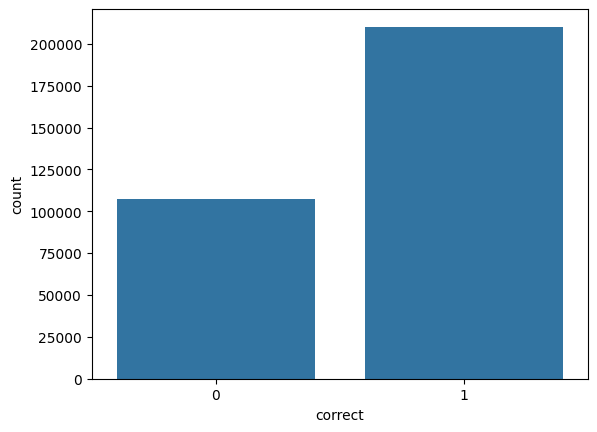

In [ ]:
# Визуализируем распределение целевой переменной correct
sns.countplot(data=df, x='correct')

In [ ]:
# Рассчитываем долю правильных и неправильных ответов
df['correct'].value_counts(normalize=True).round(3)

,proportion
correct,
1,0.662
0,0.338


Согласно представленному графику и значению value_counts правильных ответов значительно больше, чем неправильных, соотношение составляет примерно 2:1. Этот датасет умеренно несбалансирован, однако дисбаланс не является критическим. Следовательно при обучении моделей нельзя ориентироваться только на Accuracy.

In [ ]:
# Формируем матрицу признаков X и целевую переменную y для прогнозирования правильности ответа
features = [
    'original',
    'attempt_count',
    'ms_first_response',
    'answer_type',
    'position',
    'skill_name',
    'hint_total',
    'opportunity'
]

X = df[features].copy()
y = df['correct']

In [ ]:
#Уникальные значения категориальных признаков
X['answer_type'].unique()

array(['algebra', 'fill_in_1', 'choose_1', 'Other'], dtype=object)

In [ ]:
# Формируем матрицу признаков X
X['answer_type'] = pd.Categorical(X['answer_type'],categories=['algebra', 'fill_in_1', 'choose_1', 'Other'])
X_encoded = pd.get_dummies(X,columns=['answer_type', 'skill_name'],
    drop_first=True,
    dtype=int)

In [ ]:
X_encoded.shape


(317322, 118)

In [ ]:
#Проверим количество уникальных навыков
X['skill_name'].nunique()

110

In [ ]:
#Разделяем данные на тренировочные и тестовые
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y,train_size=0.8,random_state=42,stratify=y)

In [ ]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (253857, 118)
X_test: (63465, 118)
y_train: (253857,)
y_test: (63465,)


In [ ]:
# Стандартизируем признаки:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Обучаем модель Logistic Regression на тренировочной выборке
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
#Предсказание и определение вероятности положительного класса 1
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [ ]:
# Вычисляем основные метрики Logistic Regression
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score, confusion_matrix)
print(f'Accuracy : {accuracy_score(y_test, y_pred):.3f}')
print(f'Precision: {precision_score(y_test, y_pred):.3f}')
print(f'Recall   : {recall_score(y_test, y_pred):.3f}')
print(f'F1-score : {f1_score(y_test, y_pred):.3f}')

Accuracy : 0.820
Precision: 0.801
Recall   : 0.969
F1-score : 0.877


In [ ]:
from sklearn.metrics import roc_auc_score
print(f'ROC-AUC  : {roc_auc_score(y_test, y_prob):.3f}')

ROC-AUC  : 0.799


Точность 0.820 говорит о том, что модель правильно классифицирует 82% представленных данных. 80.1% предсказанных положительных случаев действительно являются положительными. 0.969 — модель выявляет 96.9% всех положительных случаев.ROC-AUC: 0.799 — модель достаточно хорошо разделяет положительный и отрицательный классы.

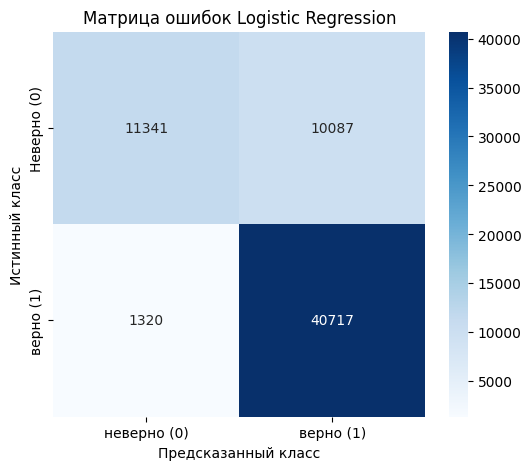

In [ ]:
# Строим матрицу ошибок для оценки качества классификации
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True,fmt='d',
    cmap='Blues',
    xticklabels=['неверно (0)', 'верно (1)'],
    yticklabels=['Неверно (0)', 'верно (1)']
)
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Матрица ошибок Logistic Regression')
plt.savefig('1.png')
plt.show()

In [ ]:
# Анализируем коэффициенты Logistic Regression
coef = pd.DataFrame({'Признак': X_encoded.columns,
    'Коэффициент': model.coef_[0]})
coef = coef.sort_values('Коэффициент', ascending=False)
coef

,Признак,Коэффициент
3,position,0.317212
7,answer_type_choose_1,0.301194
4,hint_total,0.245739
94,skill_name_Scatter Plot,0.069778
64,skill_name_Nets of 3D Figures,0.057653
...,...,...
83,skill_name_Pythagorean Theorem,-0.172568
115,skill_name_Write Linear Equation from Graph,-0.181648
32,skill_name_Counting Methods,-0.209753
80,skill_name_Probability of Two Distinct Events,-0.246289


Построим графики важности признаков


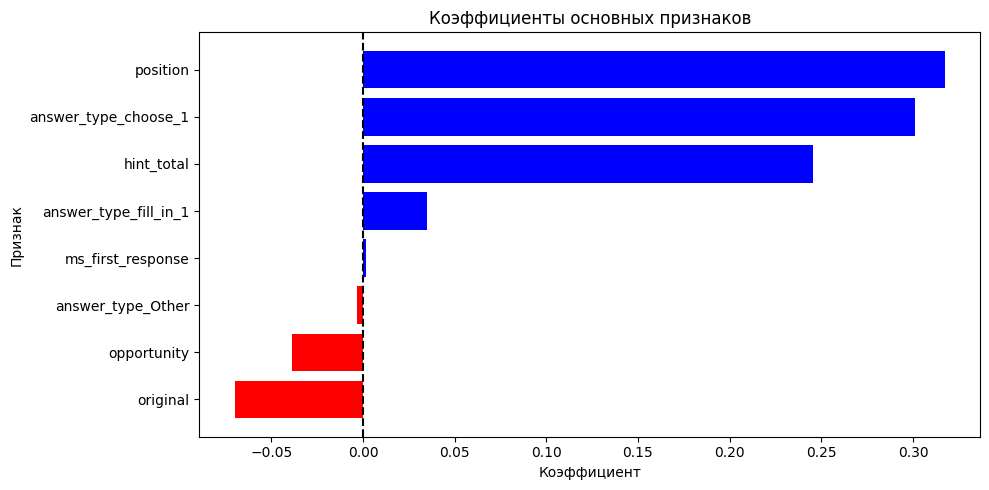

In [ ]:
#Построим график основных признаков, но attempt_count исключаем из графика, так как
#его коэффициент значительно больше по абсолютному значению и из-за этого остальные признаки становятся менее наглядными.
coef_main = coef[~coef['Признак'].str.startswith('skill_name_')]
coef_main = coef_main.sort_values('Коэффициент')
coef_main = coef_main[coef_main['Признак'] != 'attempt_count']
plt.figure(figsize=(10, 5))
plt.barh(
    coef_main['Признак'],
    coef_main['Коэффициент'],
    color=['red' if x < 0 else 'blue' for x in coef_main['Коэффициент']]
)
plt.axvline(0, color='black', linestyle='--')
plt.title('Коэффициенты основных признаков')
plt.xlabel('Коэффициент')
plt.ylabel('Признак')
plt.tight_layout()
plt.show()



Наиболее выраженную отрицательную связь с вероятностью правильного ответа в логистической регрессии имеет количество попыток решения (attempt_count, коэффициент −2,469). Это означает, что увеличение количества попыток связано со снижением вероятности правильного ответа. Среди положительных коэффициентов наиболее высокие значения имеют позиция задания (position, 0,317), тип ответа choose_1 (0,301) и количество подсказок (hint_total, 0,246).


In [ ]:
#Сравнение фактических и предсказанных результатов
comparison = pd.DataFrame({
    'Реальность': y_test.values[:10],
    'Предсказанный класс': y_pred[:10],
    'P(верно)': y_prob[:10].round(3)
})

comparison['Правильное предсказание'] = (
    comparison['Реальность'] == comparison['Предсказанный класс']
)

comparison

,Реальность,Предсказанный класс,P(верно),Правильное предсказание
0,1,1,0.849,True
1,1,1,0.824,True
2,0,1,0.642,False
3,0,0,0.044,True
4,1,1,0.794,True
5,1,1,0.749,True
6,1,1,0.876,True
7,0,0,0.003,True
8,1,1,0.782,True
9,1,1,0.832,True


In [ ]:
#Изменяем пороги
from sklearn.metrics import precision_score, recall_score, f1_score
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
results = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    results.append({
        'threshold': t,
        'precision': precision_score(y_test, y_pred_t),
        'recall': recall_score(y_test, y_pred_t),
        'f1': f1_score(y_test, y_pred_t)
    })

results_df = pd.DataFrame(results).round(3)
results_df

,threshold,precision,recall,f1
0,0.3,0.770,0.998,0.869
1,0.4,0.790,0.989,0.879
2,0.5,0.801,0.969,0.877
3,0.6,0.820,0.902,0.859
4,0.7,0.841,0.789,0.814


Таким образом, для данной модели оптимальным среди рассмотренных является порог 0.4, поскольку он обеспечивает наибольший F1-score и позволяет сохранить  высокий Recall (0.989).

#  Рассмотрим второй алгоритм — метод k ближайших соседей (k = 5)




In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
# Обучаем модель ближайших соседей на тренировочной выборке
model_N = KNeighborsClassifier(n_neighbors=5)
model_N.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [ ]:
# Получаем предсказания модели на тестовой выборке
y_pred = model_N.predict(X_test_scaled)

In [ ]:
#Проверяем размер
y_pred.shape

(63465,)

In [ ]:
# Импортируем функцию для построения матрицы ошибок
from sklearn.metrics import confusion_matrix

In [ ]:
# Строим матрицу ошибок, сравнивая реальные и предсказанные значения
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[15756  5672]
 [ 2489 39548]]


In [ ]:
# Импортируем инструмент для построения и отображения матрицы ошибок
from sklearn.metrics import ConfusionMatrixDisplay

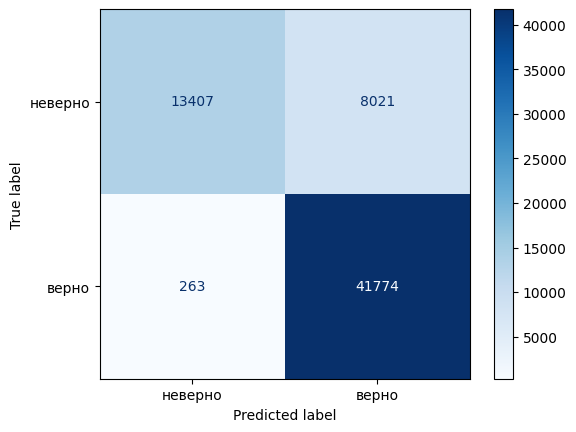

In [ ]:
# Строим визуальное представление матрицы ошибок
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['неверно', 'верно'],
    cmap = 'Blues'
)
plt.show()

In [ ]:
# Импортируем основные метрики классификации
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [ ]:
print(f'Accuracy: {accuracy_score(y_test,y_pred):.3f}')
print(f'Precision: {precision_score(y_test,y_pred):.3f}')
print(f'Recall: {recall_score(y_test,y_pred):.3f}')
print(f'f1_score: {f1_score(y_test,y_pred):.3f}')

Accuracy: 0.871
Precision: 0.875
Recall: 0.941
f1_score: 0.906


In [ ]:
# Получаем вероятность принадлежности дааных к классу «верно»
y_prob = model_N.predict_proba(X_test_scaled)[:, 1]

In [ ]:
# Импортируем метрику ROC-AUC для оценки качества классификации
from sklearn.metrics import roc_auc_score
print(f'ROC-AUC  : {roc_auc_score(y_test, y_prob):.3f}')

ROC-AUC  : 0.906


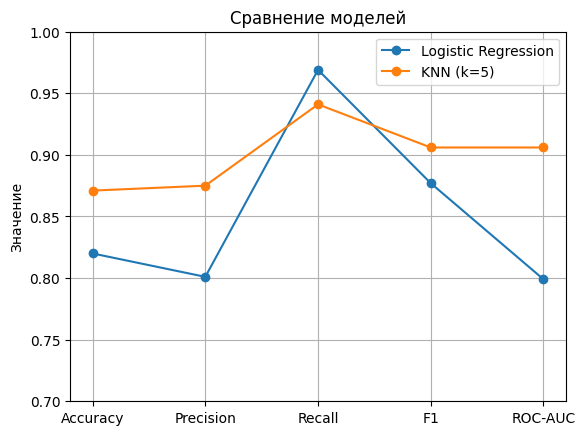

In [ ]:
#Визуализируем результаты метрик двух алгоритмов
import matplotlib.pyplot as plt
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
logistic = [0.820, 0.801, 0.969, 0.877, 0.799]
knn = [0.871, 0.875, 0.941, 0.906, 0.906]
plt.plot(metrics, logistic, marker='o', label='Logistic Regression')
plt.plot(metrics, knn, marker='o', label='KNN (k=5)')
plt.ylabel('Значение')
plt.ylim(0.7, 1.0)
plt.title('Сравнение моделей')
plt.legend()
plt.grid(True)
plt.show()

Сравнение моделей показало, что второй метод (k ближайших соседей KNN) при k=5 показал более высокое качество классификации по сравнению с логистической регрессией. Но обучение модели заняло некоторое время (до нескольких минут) Значение Accuracy увеличилось с 0,820 до 0,871, Precision — с 0,801 до 0,875, а F1-score — с 0,877 до 0,906. Значительное улучшение наблюдается и по показателю ROC-AUC: с 0,799 у логистической регрессии до 0,906 у KNN. При этом Recall логистической регрессии оказался выше (0,969 против 0,941), что говорит о её лучшей способности выявлять положительные случаи. В целом KNN показал более сбалансированное качество классификации, что позволяет рассматривать его как более эффективную модель для прогнозирования правильности ответа в данном наборе данных.




# Исследовательский вопрос №2.
# «Какие сочетания поведенческих характеристик ученика наиболее точно позволяют определить, будет ли его ответ правильным?»

In [ ]:
df = pd.read_csv('Clean_dataset.csv', encoding='latin1')

In [ ]:
# Выбираем характеристики ученика
features = [
    'attempt_count',
    'ms_first_response',
    'hint_total',
    'opportunity'
]

X = df[features].copy()
y = df['correct']

In [ ]:
# Импортируем функцию для разделения данных на train и test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,train_size=0.8,random_state=42,stratify=y)

In [ ]:
#Проверяем размеры разделенных данных
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((253857, 4), (63465, 4), (253857,), (63465,))

# Алгоритм 1. DecisionTree

In [ ]:
# Импортируем модель дерева решений для классификации
from sklearn.tree import DecisionTreeClassifier, plot_tree


In [ ]:
# Создаётся модель дерева решений (ограничим глубину до 8)
model_tree = DecisionTreeClassifier(max_depth=8, random_state=42)
model_tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=8, random_state=42)

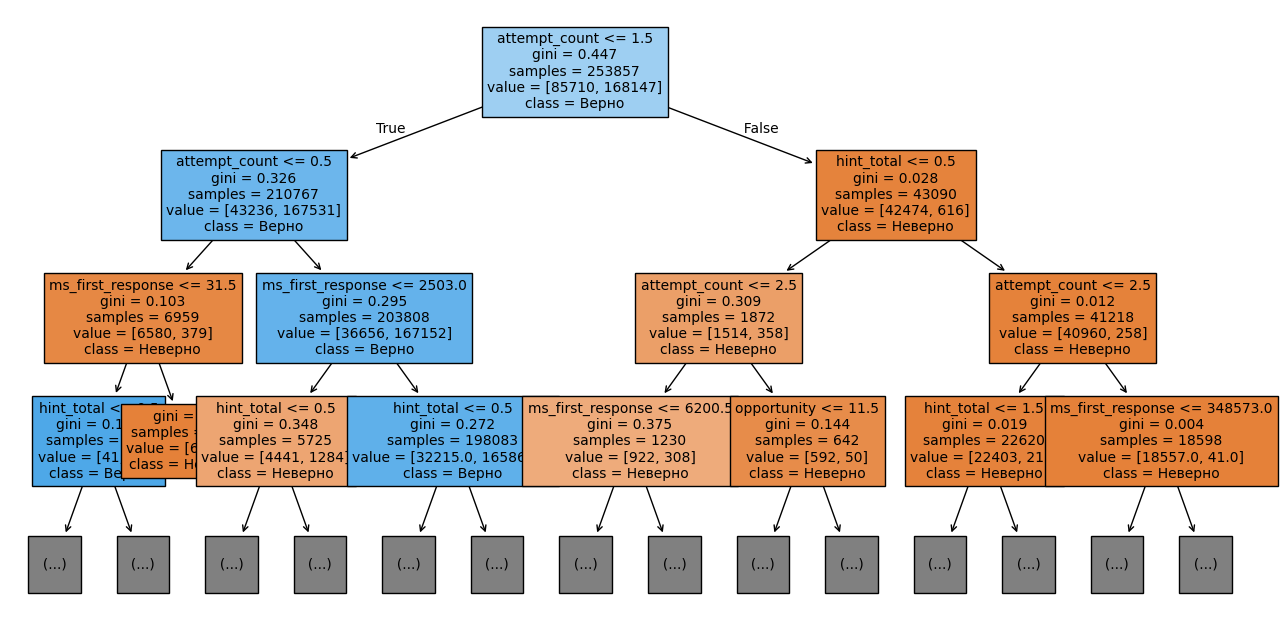

In [ ]:
# Визуализируем дерево решений
plt.figure(figsize=(16,8))
plot_tree(model_tree, feature_names=X.columns, class_names=['Неверно', 'Верно'], fontsize=10,filled=True,max_depth=3)
plt.show()

In [ ]:
# Импортируем метрики Accuracy, F1-score, precision, recall для оценки качества модели
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score


In [ ]:
# Получаем предсказания модели на тестовой выборке
y_pred = model_tree.predict(X_test)

In [ ]:
# Рассчитываем и выводим Точность и F1-score
tree_accuracy = accuracy_score(y_test, y_pred)
tree_f1 = f1_score(y_test, y_pred)
tree_precision = precision_score(y_test, y_pred)
tree_recall = recall_score(y_test, y_pred)
print(f'Accuracy: {tree_accuracy:.3f}')
print(f'F1-score: {tree_f1:.3f}')
print(f'Precision: {tree_precision:.3f}')
print(f'Recall: {tree_recall:.3f}')

Accuracy: 0.869
F1-score: 0.910
Precision: 0.839
Recall: 0.994


In [ ]:
# Создаём таблицу с названиями признаков и их важностью для дерева решений
importance = pd.DataFrame({
        'Признак': X.columns,
        'Важность':model_tree.feature_importances_
}).sort_values('Важность', ascending=False)
importance

,Признак,Важность
0,attempt_count,0.828729
1,ms_first_response,0.110904
2,hint_total,0.055460
3,opportunity,0.004906


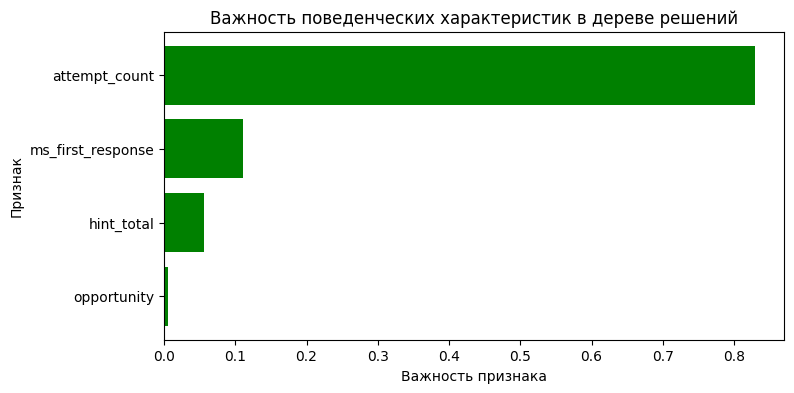

In [ ]:
# Создаем итоговый график важности признаков
plt.figure(figsize=(8, 4))
plt.barh(
    importance['Признак'][::-1],
    importance['Важность'][::-1],
    color='green'
)
plt.xlabel('Важность признака')
plt.ylabel('Признак')
plt.title('Важность поведенческих характеристик в дереве решений')
plt.show()

По результатам построения дерева решений можно сделать вывод, что главную роль играет количество попыток ученика. Этот признак оказался значительно важнее остальных: его важность составила около 82,9%. При этом дерево учитывает не только количество попыток, но использует время до первого ответа, количество использованных подсказок. То есть результат зависит от сочетания нескольких особенностей поведения ученика.Признак opportunity оказался практически незначимым для данной модели, его важность составила всего около 0,5%.



# Алгоритм 2. Random Forest

In [ ]:
# Импортируем алгоритм Random Forest
from sklearn.ensemble import RandomForestClassifier

In [ ]:
# Создаём модель случайного леса
forest = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42)
forest.fit(X_train,y_train)

RandomForestClassifier(max_depth=8, n_estimators=200, random_state=42)

In [ ]:
# Импортируем метрики Accuracy, F1-score, precision, recall для оценки качества модели
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score


In [ ]:
#Вычисляем метрики
forest_accuracy = accuracy_score(y_test, forest.predict(X_test))
forest_f1 = f1_score(y_test, forest.predict(X_test))
forest_precision = precision_score(y_test, forest.predict(X_test))
forest_recall = recall_score(y_test, forest.predict(X_test))
print(f'Accuracy леса: {forest_accuracy:.3f}')
print(f'F1_леса:{forest_f1:.3f}')
print(f'Precision_леса:{forest_precision:.3f}')
print(f'Recall_леса:{forest_recall:.3f}')

Accuracy леса: 0.870
F1_леса:0.910
Precision_леса:0.840
Recall_леса:0.992


In [ ]:
# Создаём DataFrame с важностью признаков для двух моделей: Decision Tree (DT) и Random Forest (RF)
importances = pd.DataFrame({
        'Признак': X.columns,
        'Важность DT': model_tree.feature_importances_,
        'Важность RF': forest.feature_importances_,
}).sort_values('Важность RF', ascending = False)

In [ ]:
importances

,Признак,Важность DT,Важность RF
0,attempt_count,0.828729,0.834677
1,ms_first_response,0.110904,0.111108
2,hint_total,0.055460,0.048109
3,opportunity,0.004906,0.006106


In [ ]:
# Импортируем GridSearchCV для поиска оптимальных гиперпараметров модели
from sklearn.model_selection import GridSearchCV

In [ ]:
# Задаём гиперпараметры, которые GridSearchCV будет перебирать
param_grid = {
    'n_estimators': [50,100,150,200],
    'max_depth': [3,5,7,8],
    'min_samples_leaf': [1,5,10]
}
grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
                    param_grid, cv = 5, scoring='f1',n_jobs=-1)
grid.fit(X_train,y_train)

print(f'Лучшие параметры, {grid.best_params_}')
print(f'Лучший F1, {grid.best_score_}')

Лучшие параметры, {'max_depth': 8, 'min_samples_leaf': 1, 'n_estimators': 50}
Лучший F1, 0.9096141263685953


In [ ]:
# Создаём таблицу для сравнения метрик двух моделей
metrics = pd.DataFrame({
    'Метрика': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
     'Decision Tree': [tree_accuracy, tree_precision, tree_recall, tree_f1],
     'Random Forest': [forest_accuracy, forest_precision, forest_recall, forest_f1]
})
metrics = metrics.round(3)
# Выводим таблицу
print(metrics)

     Метрика  Decision Tree  Random Forest
0   Accuracy          0.869          0.870
1  Precision          0.839          0.840
2     Recall          0.994          0.992
3   F1-score          0.910          0.910


В целом обе модели показывают очень близкие результаты. Random Forest немного лучше по Accuracy и Precision, а Decision Tree немного лучше по Recall. При этом F1-score у обеих моделей одинаковый — 0.910. Можно сделать вывод, что существенной разницы в качестве моделей нет, однако Random Forest показывает чуть более стабильный результат по большинству метрик.

## №3. Как учебный навык и время до первого ответа ученика совместно связаны с успешностью выполнения задания?»

In [ ]:
#Загружаем необходимые библиотеки и очищенный датасет
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('Clean_dataset.csv', encoding='latin1')

In [ ]:
# Выбираем учебный навык и время до первого ответа
features = ['skill_name','ms_first_response']
X = df[features].copy()
y = df['correct']

In [ ]:
# Разделяем данные на обучающую и тестовую выборки
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,train_size=0.8, random_state=42,stratify=y)

# Алгоритм 1. Catboost

In [ ]:
# Устанавливаем библиотеку CatBoost для обучения моделей машинного обучения
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 5.9 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostClassifier
# Создаём модель CatBoost
model_cat = CatBoostClassifier(iterations=500,depth=6,learning_rate=0.05,l2_leaf_reg=5,eval_metric='AUC',random_seed=42,verbose=0)

In [ ]:
# Обучаем модель на обучающей выборке и skill_name передаём как категориальный признак
model_cat.fit(X_train,y_train,cat_features=['skill_name'])

CatBoostClassifier(depth=6, eval_metric='AUC', iterations=500, l2_leaf_reg=5, learning_rate=0.05, random_seed=42, verbose=0)

In [ ]:
# Предсказания модели на тестовой выборке
y_pred = model_cat.predict(X_test)

In [ ]:
# Получаем вероятности правильного ответа
y_prob = model_cat.predict_proba(X_test)[:, 1]

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
# Рассчитываем метрики качества модели
print(f'Accuracy: {accuracy_score(y_test, y_pred):.3f}')
print(f'F1-score: {f1_score(y_test, y_pred):.3f}')
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob):.3f}')

Accuracy: 0.700
F1-score: 0.808
ROC-AUC: 0.683


Модель CatBoost, использующая учебный навык и время до первого ответа, показала Accuracy 70%, F1-score 0,808 и ROC-AUC 0,683.

# Алгоритм 2. KNN

In [ ]:
# Выбираем признаки и целевую переменную
features = ['skill_name', 'ms_first_response']
X = df[features].copy()
y = df['correct']

In [ ]:
#Преобразуем skill_name в dummy-признаки
X = pd.get_dummies(X,columns=['skill_name'],drop_first=True)

In [ ]:
#Разделяем данные на train и test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8,random_state=42,stratify=y)

In [ ]:
# Масштабируем числовой признак
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Создаём KNN
from sklearn.neighbors import KNeighborsClassifier
model_knn = KNeighborsClassifier(n_neighbors=5,weights='distance',metric='euclidean',n_jobs=-1)

In [ ]:
# Обучаем модель
model_knn.fit(X_train_scaled, y_train)

KNeighborsClassifier(metric='euclidean', n_jobs=-1, weights='distance')

In [ ]:
# Предсказываем классы
y_pred = model_knn.predict(X_test_scaled)
# Получаем вероятности
y_prob = model_knn.predict_proba(X_test_scaled)[:, 1]

In [ ]:
# Рассчитываем метрики
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
accuracy = accuracy_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)
roc_auc = roc_auc_score(y_test,y_prob)

In [ ]:
# Выводим результаты
print(f"Accuracy: {accuracy:.3f}")
print(f"F1-score: {f1:.3f}")
print(f"ROC-AUC: {roc_auc:.3f}")

Accuracy: 0.714
F1-score: 0.790
ROC-AUC: 0.743


KNN показал хороший результат. Accuracy составила 0.714, то есть модель правильно классифицирует около 71,4% ответов. F1-score равен 0.790, что говорит о достаточно хорошем балансе между точностью и полнотой предсказаний. ROC-AUC = 0.743 значительно больше чем 0,683.Таким образом, KNN оказался наиболее эффективным алгоритмом для данного исследовательского вопроса по ROC-AUC и Accuracy.

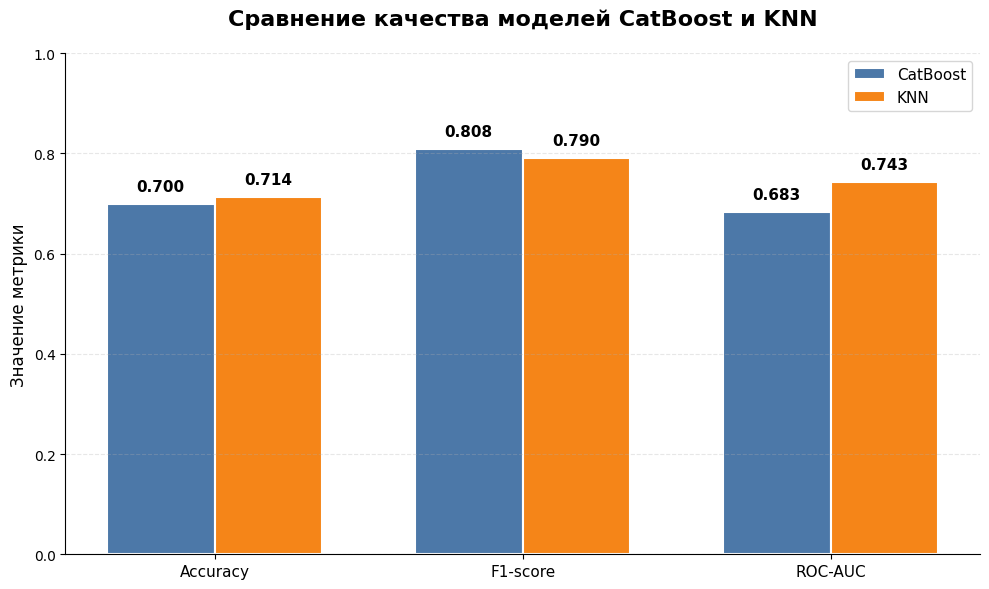

In [7]:
metrics = ['Accuracy', 'F1-score', 'ROC-AUC']
catboost = [0.700, 0.808, 0.683]
knn = [0.714, 0.790, 0.743]
x = np.arange(len(metrics))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2,catboost,width,label='CatBoost',color='#4C78A8',edgecolor='white',linewidth=1.5)
bars2 = ax.bar(x + width/2,knn,width,label='KNN',color='#F58518',edgecolor='white',linewidth=1.5)
ax.set_title('Сравнение качества моделей CatBoost и KNN',
    fontsize=16,
    fontweight='bold',
    pad=20)
ax.set_ylabel('Значение метрики', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1)
ax.grid(axis='y',linestyle='--',alpha=0.3)
def add_values(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.02,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            fontsize=11,
            fontweight='bold'
        )
ax.legend(fontsize=11,loc='upper right', frameon=True)
add_values(bars1)
add_values(bars2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
# Разделяем время до первого ответа на группы
df['response_time_group'] = pd.cut(
    df['ms_first_response'],bins=[-1, 10000, 30000, 60000, 120000, float('inf')],
    labels=[
        'до 10 сек',
        '10–30 сек',
        '30–60 сек',
        '60–120 сек',
        'более 120 сек'
    ]
)

In [ ]:
# Считаем количество ответов и долю правильных ответов
time_stats = df.groupby('response_time_group', observed=True)['correct'].agg(['count', 'mean'])
time_stats['mean'] = time_stats['mean'] * 100
time_stats

,count,mean
response_time_group,,
до 10 сек,86383,64.702546
10–30 сек,112171,71.428444
30–60 сек,60828,65.187085
60–120 сек,37853,60.880247
более 120 сек,20087,57.116543


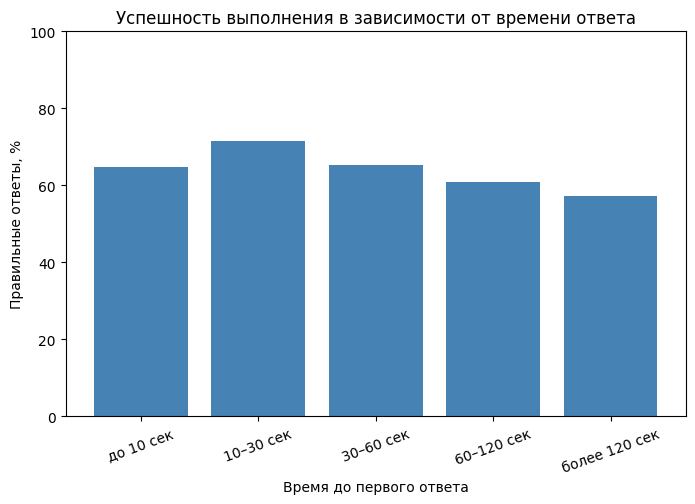

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(time_stats.index,time_stats['mean'],color='steelblue')
plt.xlabel('Время до первого ответа')
plt.ylabel('Правильные ответы, %')
plt.title('Успешность выполнения в зависимости от времени ответа')
plt.xticks(rotation=20)
plt.ylim(0, 100)
plt.show()

Анализ показал, что успешность выполнения заданий различается в зависимости от времени до первого ответа. При этом характер зависимости может отличаться для разных учебных навыков.